In [ ]:
#importing weather data for Osnabrueck
import pandas as pd
import requests
# URL of the webpage containing JSON data
url = "http://139.174.11.24/data?dataset=weatherdataforcities&start=2019-01-01&end=2023-12-31&cityName=Osnabrueck"

# Fetch the data from the URL
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Parse JSON data
    Osna_data = response.json()

    # Convert the data to a DataFrame
    Osna_df = pd.DataFrame.from_dict(Osna_data , orient='index')

    # Reset the index to convert the timestamp to a column
    Osna_df.reset_index(inplace=True)

else:
    print("Failed to fetch data. Status code:", response.status_code)





In [ ]:
Osna_df.shape

(43824, 14)

In [ ]:

# drop unwanted columns
Osna_df = Osna_df.drop(columns = ["index", "time","snow","cityName"])
Osna_df
Osna_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   temp    43824 non-null  float64
 1   dwpt    43824 non-null  float64
 2   rhum    43824 non-null  float64
 3   prcp    43824 non-null  float64
 4   wdir    43824 non-null  float64
 5   wspd    43824 non-null  float64
 6   wpgt    43824 non-null  float64
 7   pres    43824 non-null  float64
 8   tsun    43820 non-null  float64
 9   coco    43824 non-null  float64
dtypes: float64(10)
memory usage: 3.3 MB


In [ ]:
Osna_df.head()

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
0,7.6,6.4,92.0,0.0,250.0,18.4,31.0,1030.5,0.0,7.0
1,7.1,6.0,93.0,0.1,240.0,20.9,35.0,1029.7,0.0,7.0
2,7.4,5.4,87.0,0.1,250.0,23.8,39.0,1029.1,0.0,4.0
3,7.5,5.5,87.0,0.0,240.0,23.0,35.0,1028.3,0.0,4.0
4,7.4,5.0,85.0,0.0,240.0,25.6,38.0,1027.3,0.0,4.0


In [ ]:
#Checking for null values
Osna_df.isnull().sum()

temp    0
dwpt    0
rhum    0
prcp    0
wdir    0
wspd    0
wpgt    0
pres    0
tsun    4
coco    0
dtype: int64

In [ ]:
# find the percentage of missing values in each feature
Osna_df.isnull().sum()/len(Osna_df) *100

temp    0.000000
dwpt    0.000000
rhum    0.000000
prcp    0.000000
wdir    0.000000
wspd    0.000000
wpgt    0.000000
pres    0.000000
tsun    0.009127
coco    0.000000
dtype: float64

In [ ]:
mask_nntsun = Osna_df['tsun'].isnull()
Osna_df[mask_nntsun]

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
29723,22.1,11.5,51.0,0.0,130.0,15.8,28.0,1002.1,NaN,4.0
29724,24.5,12.5,47.0,0.0,130.0,15.1,32.0,1001.0,NaN,4.0
29725,24.6,12.9,48.0,0.0,130.0,15.5,31.0,999.9,NaN,4.0
29726,25.3,12.2,44.0,0.0,130.0,13.3,26.0,999.0,NaN,4.0


In [ ]:
missing_indices = [29723, 29724,29725,29726]

# Perform linear interpolation specifically for the given indices
Osna_df.loc[missing_indices, 'tsun'] = Osna_df['tsun'].interpolate(method='linear')[missing_indices]

In [ ]:
#Check if missing values still exists for the tsun feature
Osna_df.isnull().sum()/len(Osna_df) *100

temp    0.0
dwpt    0.0
rhum    0.0
prcp    0.0
wdir    0.0
wspd    0.0
wpgt    0.0
pres    0.0
tsun    0.0
coco    0.0
dtype: float64

In [ ]:

Osna_df.isnull().sum()

temp    0
dwpt    0
rhum    0
prcp    0
wdir    0
wspd    0
wpgt    0
pres    0
tsun    4
coco    0
dtype: int64

In [ ]:
# Check if -99999 exists in all columns and print columns where it exists
columns_with_value = Osna_df.apply(lambda col: col.name if -99999 in col.values else None).dropna()

if len(columns_with_value) > 0:
    print(f"The value '{-99999}' exists in the following columns:")
    for col in columns_with_value:
        print(col)
else:
    print(f"The value '{-99999}' does not exist in any column.")

The value '-99999' does not exist in any column.


In [ ]:
Osna_df.describe()

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
count,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,11.254114,6.584091,76.054696,0.080620,185.604167,11.922328,22.001883,1015.571803,11.762139,4.117150
std,7.286744,5.717004,18.345825,0.442617,89.882863,7.666718,13.174718,10.353448,21.125418,2.962554
min,-17.300000,-18.800000,13.000000,0.000000,0.000000,0.400000,2.000000,971.800000,0.000000,0.000000
25%,5.900000,2.400000,64.000000,0.000000,120.000000,6.100000,12.000000,1009.300000,0.000000,3.000000
50%,10.700000,6.700000,81.000000,0.000000,200.000000,10.400000,20.000000,1016.300000,0.000000,4.000000
75%,16.400000,11.000000,91.000000,0.000000,250.000000,16.200000,30.000000,1022.300000,13.000000,4.000000
max,39.600000,22.300000,100.000000,22.400000,360.000000,69.500000,122.000000,1048.300000,60.000000,26.000000


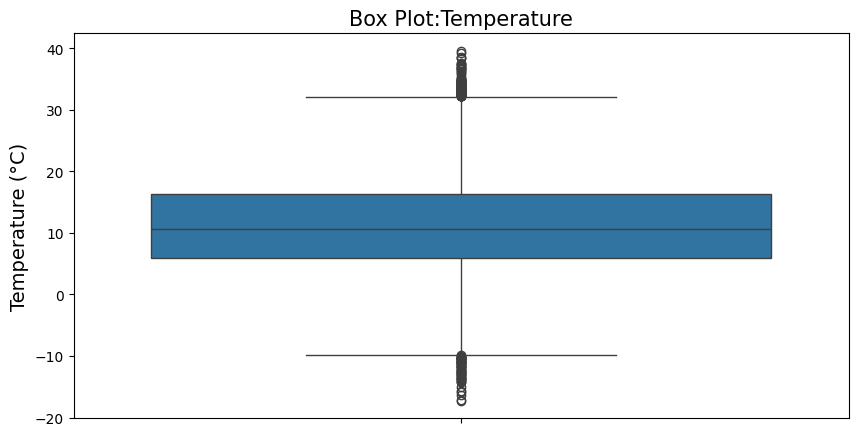

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig = plt.figure(figsize=(10,5))
sns.boxplot(Osna_df.temp)
plt.title('Box Plot:Temperature', fontsize=15)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.show()

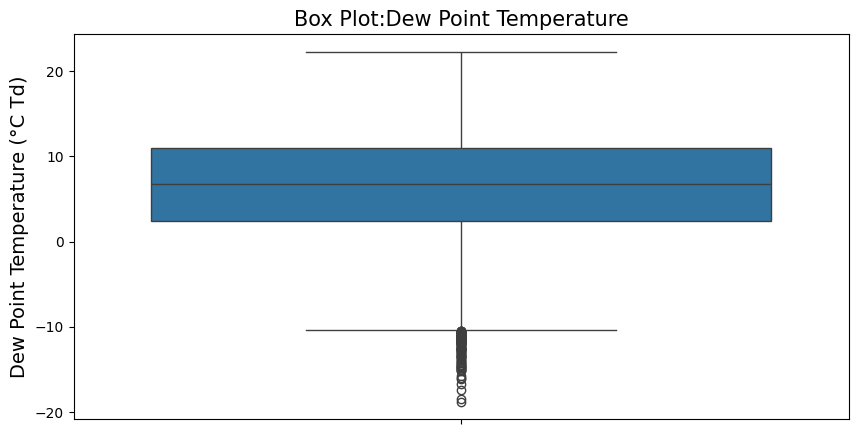

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Osna_df.dwpt)
plt.title('Box Plot:Dew Point Temperature', fontsize=15)
plt.ylabel('Dew Point Temperature (°C Td)', fontsize=14)
plt.show()

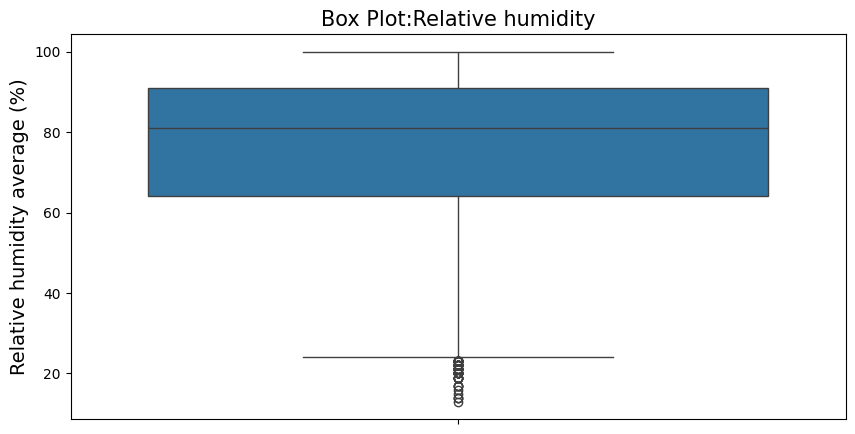

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Osna_df.rhum)
plt.title('Box Plot:Relative humidity', fontsize=15)
plt.ylabel('Relative humidity average (%)', fontsize=14)
plt.show()

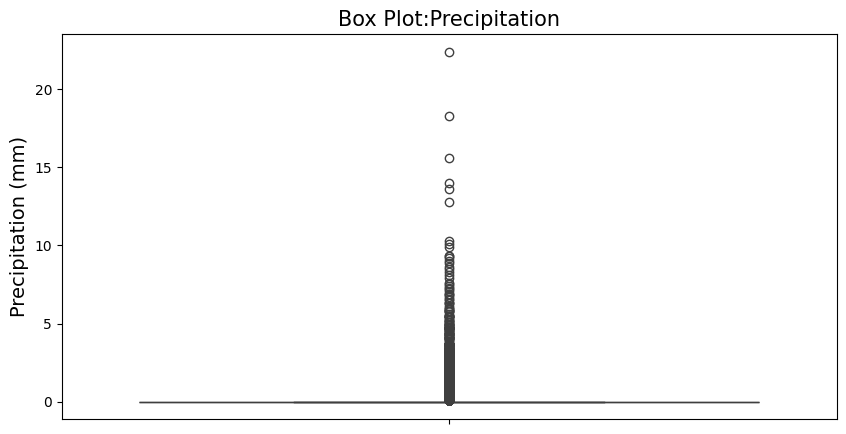

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Osna_df.prcp)
plt.title('Box Plot:Precipitation', fontsize=15)
plt.ylabel('Precipitation (mm)', fontsize=14)
plt.show()

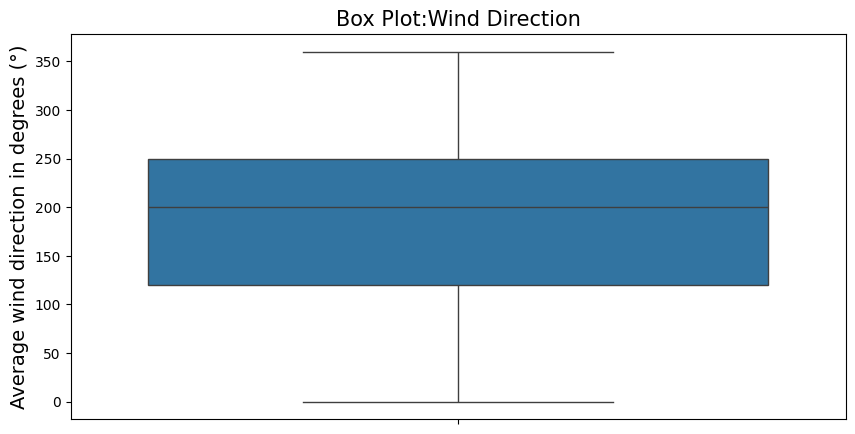

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Osna_df.wdir)
plt.title('Box Plot:Wind Direction', fontsize=15)
plt.ylabel('Average wind direction in degrees (°)', fontsize=14)
plt.show()

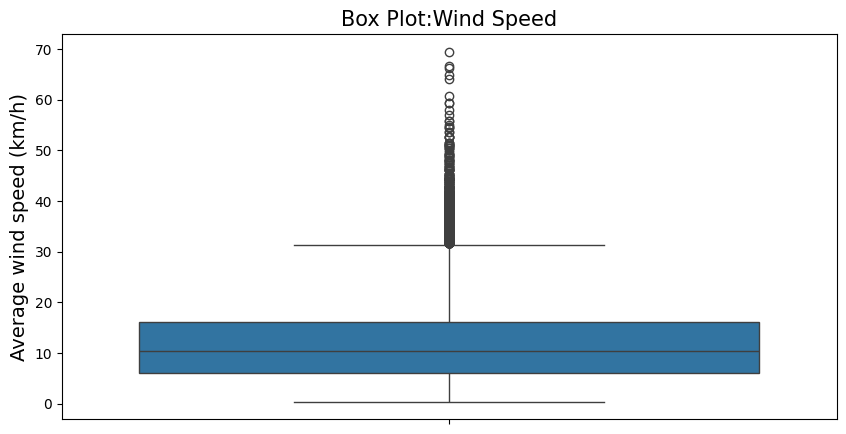

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Osna_df.wspd)
plt.title('Box Plot:Wind Speed', fontsize=15)
plt.ylabel('Average wind speed (km/h)', fontsize=14)
plt.show()

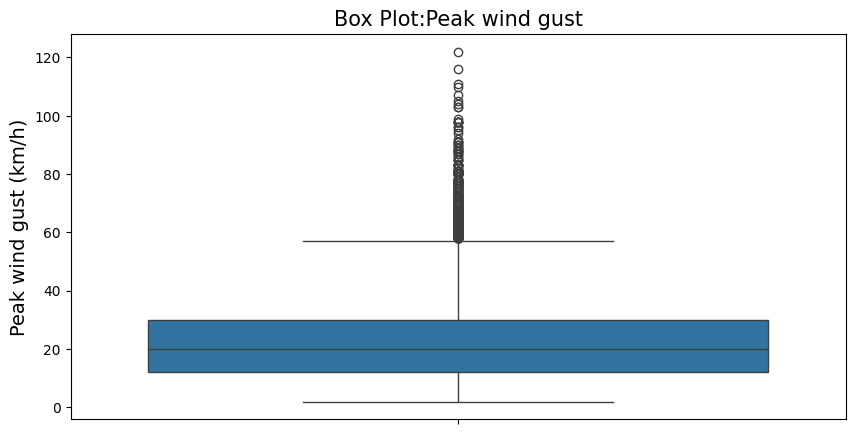

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Osna_df.wpgt)
plt.title('Box Plot:Peak wind gust', fontsize=15)
plt.ylabel('Peak wind gust (km/h)', fontsize=14)
plt.show()

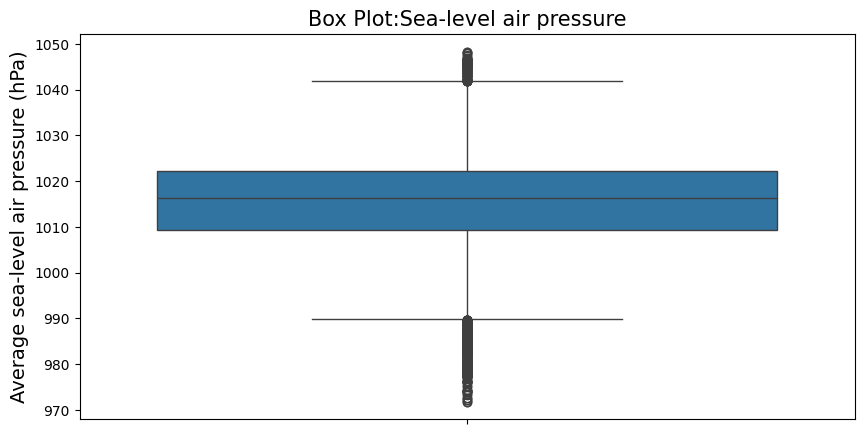

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Osna_df.pres)
plt.title('Box Plot:Sea-level air pressure', fontsize=15)
plt.ylabel('Average sea-level air pressure (hPa)', fontsize=14)
plt.show()

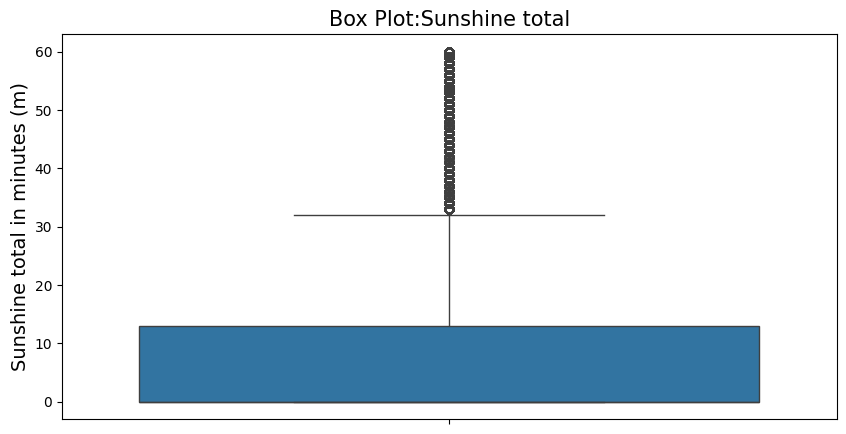

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Osna_df.tsun)
plt.title('Box Plot:Sunshine total', fontsize=15)
plt.ylabel('Sunshine total in minutes (m)', fontsize=14)
plt.show()

In [ ]:
Osna_df["tsun"].max()

60.0

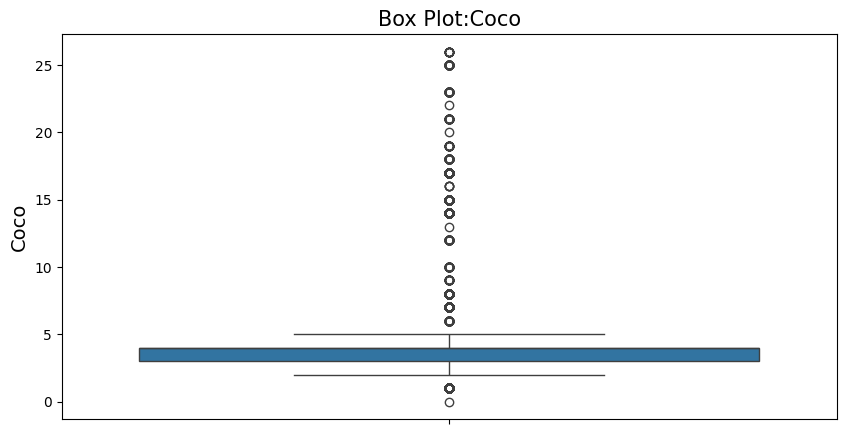

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Osna_df.coco)
plt.title('Box Plot:Coco', fontsize=15)
plt.ylabel('Coco', fontsize=14)
plt.show()

In [ ]:
mask_ntsun = Osna_df['tsun'] > 0.0
Osna_df[mask_ntsun]

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
12,8.2,5.3,82.0,0.0,290.0,21.2,43.0,1025.0,3.0,3.0
13,8.3,2.7,68.0,0.0,300.0,23.8,44.0,1025.0,22.0,3.0
14,7.7,2.8,71.0,0.0,290.0,25.9,44.0,1025.1,1.0,3.0
15,7.3,3.0,74.0,0.0,280.0,25.2,55.0,1025.0,5.0,17.0
33,4.7,-0.3,70.0,0.0,310.0,13.0,26.0,1033.5,23.0,2.0
...,...,...,...,...,...,...,...,...,...,...
43765,10.9,6.6,75.0,0.0,240.0,33.8,60.0,1006.3,4.0,4.0
43786,7.5,4.6,82.0,0.0,230.0,19.1,31.0,1012.9,8.0,4.0
43787,7.8,5.1,83.0,0.0,230.0,22.7,37.0,1013.1,22.0,3.0
43788,8.2,5.3,82.0,0.0,240.0,19.8,33.0,1013.1,2.0,4.0


In [ ]:
mask_tsun = Osna_df['tsun'] == 0.0
mask_prcp = Osna_df['prcp'] ==0.0
Osna_df[mask_tsun & mask_prcp]

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
0,7.6,6.4,92.0,0.0,250.0,18.4,31.0,1030.5,0.0,7.0
3,7.5,5.5,87.0,0.0,240.0,23.0,35.0,1028.3,0.0,4.0
4,7.4,5.0,85.0,0.0,240.0,25.6,38.0,1027.3,0.0,4.0
5,7.4,5.2,86.0,0.0,250.0,28.4,46.0,1026.7,0.0,4.0
6,7.4,5.4,87.0,0.0,250.0,30.2,46.0,1026.3,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...
43818,8.1,3.9,75.0,0.0,170.0,16.9,31.0,998.5,0.0,8.0
43819,8.2,3.6,73.0,0.0,160.0,18.4,31.0,998.7,0.0,8.0
43820,9.3,3.3,66.0,0.0,180.0,21.6,44.0,998.7,0.0,8.0
43821,9.0,3.4,68.0,0.0,190.0,25.2,47.0,999.0,0.0,8.0


APPLYING LOF FOR WEATHER DATASET FEATURES

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor


# Number of neighbors for LOF
n_neighbors = 20
contamination = 0.10
# Dictionary to store the percentage of outliers for each feature
outlier_percentages = {}

# Apply LOF to each feature
for feature in Osna_df.columns:
# Reshape the data for LOF
 X = Osna_df[[feature]].values

 # Fit the LOF model
 lof = LocalOutlierFactor(n_neighbors=n_neighbors)
 y_pred = lof.fit_predict(X)

 # Identify the outliers
 outliers = y_pred == -1

 # Calculate the percentage of outliers
 percentage_outliers = np.mean(outliers) * 100
 outlier_percentages[feature] = percentage_outliers

 print(f'Percentage of outliers in osnabruk weather in {feature}: {percentage_outliers:.2f}%')

Percentage of outliers in osnabruk weather in temp: 0.56%
Percentage of outliers in osnabruk weather in dwpt: 0.21%
Percentage of outliers in osnabruk weather in rhum: 0.02%
Percentage of outliers in osnabruk weather in prcp: 0.06%
Percentage of outliers in osnabruk weather in wdir: 0.05%
Percentage of outliers in osnabruk weather in wspd: 0.12%
Percentage of outliers in osnabruk weather in wpgt: 0.34%
Percentage of outliers in osnabruk weather in pres: 0.67%
Percentage of outliers in osnabruk weather in tsun: 0.00%
Percentage of outliers in osnabruk weather in coco: 0.05%


USING NAIVE BAYES FOR THE WEATHER DATASET

In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm


# Extract features
X = Osna_df.values

# Fit Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable

# Calculate likelihoods for each data point
means = gnb.theta_
variances = gnb.var_
likelihoods = np.zeros(X.shape[0])

# Ensure means and variances are in correct shape
if means.ndim == 1:
    means = means.reshape(1, -1)
if variances.ndim == 1:
    variances = variances.reshape(1, -1)

# Calculate likelihoods for each data point
for i, x in enumerate(X):
    likelihood = 1
    for j in range(X.shape[1]):
        likelihood *= norm.pdf(x[j], loc=means[0][j], scale=np.sqrt(variances[0][j]))
    likelihoods[i] = likelihood

# Determine anomalies
threshold = np.percentile(likelihoods, 10)  # for example, consider the bottom 10% as anomalies
anomalies = np.where(likelihoods < threshold)[0]

# Calculate percentage of anomalies for each feature
anomalies_Osna_df = Osna_df.iloc[anomalies]
total_anomalies = len(anomalies)
total_data_points = len(Osna_df)

# Calculate anomaly percentage for each feature
feature_anomalies_percentage = {}
for feature in Osna_df.columns:
    feature_anomalies_count = (anomalies_Osna_df[feature] != Osna_df[feature].mode().iloc[0]).sum()
    feature_anomalies_percentage[feature] = (feature_anomalies_count / total_data_points) * 100

print("Number of anomalies detected:", total_anomalies)
print("Percentage of anomalies for each feature:")
for feature, percentage in feature_anomalies_percentage.items():
    print(f"{feature}: {percentage:.2f}%")


Number of anomalies detected: 4383
Percentage of anomalies for each feature:
temp: 9.95%
dwpt: 9.94%
rhum: 9.72%
prcp: 3.28%
wdir: 9.50%
wspd: 9.86%
wpgt: 9.76%
pres: 9.96%
tsun: 4.80%
coco: 8.85%


NAIVE BAYES 2

In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm



# Initialize a dictionary to store anomaly information for each feature
anomaly_info = {}

# Loop through each feature
for feature in Osna_df.columns:
    # Extract the feature values
    X = Osna_df[[feature]].values

    # Fit Gaussian Naive Bayes model
    gnb = GaussianNB()
    gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable

    # Calculate likelihoods for each data point
    means = gnb.theta_
    variances = gnb.var_
    likelihoods = np.zeros(X.shape[0])

    # Ensure means and variances are in correct shape
    if means.ndim == 1:
        means = means.reshape(1, -1)
    if variances.ndim == 1:
        variances = variances.reshape(1, -1)

    # Calculate likelihoods for each data point
    for i, x in enumerate(X):
        likelihood = norm.pdf(x[0], loc=means[0][0], scale=np.sqrt(variances[0][0]))
        likelihoods[i] = likelihood

    # Determine anomalies using mean and standard deviation
    mean_likelihood = np.mean(likelihoods)
    std_likelihood = np.std(likelihoods)
    threshold = mean_likelihood - 2 * std_likelihood  # 2 standard deviations below the mean
    anomalies = np.where(likelihoods < threshold)[0]

    # Calculate percentage of anomalies for this feature
    total_anomalies = len(anomalies)
    total_data_points = len(Osna_df)
    anomaly_percentage = (total_anomalies / total_data_points) * 100

    # Store the anomaly information
    anomaly_info[feature] = {
        'total_anomalies': total_anomalies,
        'anomaly_percentage': anomaly_percentage,
        'anomalies': anomalies
    }

# Print results
for feature, info in anomaly_info.items():
    print(f"Feature: {feature}")
    print(f"  Number of anomalies detected: {info['total_anomalies']}")
    print(f"  Percentage of anomalies: {info['anomaly_percentage']:.2f}%")



Feature: temp
  Number of anomalies detected: 2057
  Percentage of anomalies: 4.69%
Feature: dwpt
  Number of anomalies detected: 1706
  Percentage of anomalies: 3.89%
Feature: rhum
  Number of anomalies detected: 2647
  Percentage of anomalies: 6.04%
Feature: prcp
  Number of anomalies detected: 1819
  Percentage of anomalies: 4.15%
Feature: wdir
  Number of anomalies detected: 19
  Percentage of anomalies: 0.04%
Feature: wspd
  Number of anomalies detected: 2589
  Percentage of anomalies: 5.91%
Feature: wpgt
  Number of anomalies detected: 2565
  Percentage of anomalies: 5.85%
Feature: pres
  Number of anomalies detected: 2699
  Percentage of anomalies: 6.16%
Feature: tsun
  Number of anomalies detected: 5727
  Percentage of anomalies: 13.07%
Feature: coco
  Number of anomalies detected: 1294
  Percentage of anomalies: 2.95%


AUTOENCODER ON WEATHER

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential

#to save all features
features_auto_w = Osna_df.columns.tolist()


# DataFrame to store anomaly scores for each feature
anomaly_scores_auto_w = pd.DataFrame(index=Osna_df.index)

# Loop through each feature
for feature in features_auto_w :
    # Scale the feature data
    scaler = MinMaxScaler()
    scaled_feature_auto_w  = scaler.fit_transform(Osna_df[[feature]])

    # Define the autoencoder model
    model_auto_w  = Sequential([
        Dense(32, activation='relu', input_shape=(1,)),
        Dense(16, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model_auto_w .compile(optimizer='adam', loss='mean_squared_error')

     #Train the autoencoder
    model_auto_w.fit(scaled_feature_auto_w , scaled_feature_auto_w , epochs=50, batch_size=32, validation_split=0.1, verbose=0)

    # Get reconstruction loss
    reconstructed_feature_auto_w  = model_auto_w.predict(scaled_feature_auto_w )
    reconstruction_loss_auto_w  = np.mean(np.square(scaled_feature_auto_w  - reconstructed_feature_auto_w ), axis=1)

    # Store the reconstruction loss (anomaly score) in the DataFrame
    anomaly_scores_auto_w [feature] = reconstruction_loss_auto_w



1370/1370 [==============================] - 2s 1ms/step


In [ ]:

print(reconstruction_loss_auto_w)
# Calculate the threshold as the 90th percentile of the reconstruction loss
threshold_auto_w = np.percentile(reconstruction_loss_auto_w, 90)

    # Identify anomalies
anomalies_auto_w = reconstruction_loss_auto_w > threshold_auto_w

for feature in features_auto_w:
    anomalies_auto_w = anomaly_scores_auto_w[feature] > threshold_auto_w
    anomaly_percentage_auto_w = np.mean(anomalies_auto_w) * 100
    print(f'Feature: {feature}, Anomaly Percentage: {anomaly_percentage_auto_w:.2f}%')


    # Store the reconstruction loss (anomaly score) in the DataFrame
anomaly_scores_auto_w[feature] = reconstruction_loss_auto_w


# Combine anomaly scores with original data for easier analysis
combined_data_auto_w = pd.concat([Osna_df, anomaly_scores_auto_w.add_suffix('_anomaly_score')], axis=1)

# Save the combined data with anomaly scores
combined_data_auto_w.to_csv('Osna_df_with_anomaly_scores_auto_w.csv', index=False)

# Display the first few rows of the combined data
combined_data_auto_w.head()

[1.19363730e-06 1.19363730e-06 5.59971215e-07 ... 7.62252092e-07
 7.62252092e-07 7.62252092e-07]
Feature: temp, Anomaly Percentage: 78.79%
Feature: dwpt, Anomaly Percentage: 64.85%
Feature: rhum, Anomaly Percentage: 83.84%
Feature: prcp, Anomaly Percentage: 0.20%
Feature: wdir, Anomaly Percentage: 81.16%
Feature: wspd, Anomaly Percentage: 50.76%
Feature: wpgt, Anomaly Percentage: 56.94%
Feature: pres, Anomaly Percentage: 82.80%
Feature: tsun, Anomaly Percentage: 26.55%
Feature: coco, Anomaly Percentage: 3.43%


,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco,temp_anomaly_score,dwpt_anomaly_score,rhum_anomaly_score,prcp_anomaly_score,wdir_anomaly_score,wspd_anomaly_score,wpgt_anomaly_score,pres_anomaly_score,tsun_anomaly_score,coco_anomaly_score
0,7.6,6.4,92.0,0.0,250.0,18.4,31.0,1030.5,0.0,7.0,0.000006,8.859090e-07,0.000013,8.258028e-09,0.000002,3.911762e-06,7.467346e-08,7.236118e-06,5.325968e-07,1.193637e-06
1,7.1,6.0,93.0,0.1,240.0,20.9,35.0,1029.7,0.0,7.0,0.000007,4.827850e-07,0.000010,1.095713e-07,0.000002,1.096718e-06,1.405581e-06,2.856959e-06,5.325968e-07,1.193637e-06
2,7.4,5.4,87.0,0.1,250.0,23.8,39.0,1029.1,0.0,4.0,0.000006,2.202346e-07,0.000027,1.095713e-07,0.000002,1.010514e-05,5.228072e-06,1.225234e-06,5.325968e-07,5.599712e-07
3,7.5,5.5,87.0,0.0,240.0,23.0,35.0,1028.3,0.0,4.0,0.000006,2.456841e-07,0.000027,8.258028e-09,0.000002,5.163341e-06,1.405581e-06,3.010769e-07,5.325968e-07,5.599712e-07
4,7.4,5.0,85.0,0.0,240.0,25.6,38.0,1027.3,0.0,4.0,0.000006,1.639152e-07,0.000049,8.258028e-09,0.000002,3.901148e-08,6.278243e-06,3.924736e-08,5.325968e-07,5.599712e-07


USING XGBOOST ON WEATHER DATASET

In [ ]:

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error


# Define anomaly detection function
def detect_anomalies(df):
    anomalies = pd.DataFrame(index=df.index)
    anomaly_percentages = {}

    for feature in df.columns:
        X = df.drop(columns=[feature])
        y = df[feature]

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Train XGBoost model
        model = XGBRegressor()
        model.fit(X_train, y_train)

        # Predict on the whole dataset
        y_pred = model.predict(X)

        # Calculate prediction errors
        errors = np.abs(y - y_pred)

        # Determine dynamic threshold using standard deviation
        mean_error = np.mean(errors)
        std_error = np.std(errors)
        threshold = mean_error + 2 * std_error  # Consider 2 standard deviations from the mean

        # Flag anomalies
        anomaly_flags = errors > threshold
        anomalies[feature] = anomaly_flags

        # Calculate anomaly percentage
        anomaly_percentages[feature] = (anomaly_flags.sum() / len(df)) * 100

        # Print summary
        print(f"Feature: {feature}")
        print(f"Threshold: {threshold:.4f}")
        print(f"Anomalies detected: {anomaly_flags.sum()}/{len(df)} ({anomaly_percentages[feature]:.2f}%)")
        print("-" * 40)

    return anomalies, anomaly_percentages

# Detect anomalies
anomalies_df, anomaly_percentages = detect_anomalies(Osna_df)


# Print anomaly percentages
print("\nAnomaly Percentages per Feature:")
for feature, percentage in anomaly_percentages.items():
    print(f"{feature}: {percentage:.2f}%")


Feature: temp
Threshold: 0.3041
Anomalies detected: 1488/43824 (3.40%)
----------------------------------------
Feature: dwpt
Threshold: 0.3209
Anomalies detected: 1126/43824 (2.57%)
----------------------------------------
Feature: rhum
Threshold: 2.2991
Anomalies detected: 1946/43824 (4.44%)
----------------------------------------
Feature: prcp
Threshold: 0.4607
Anomalies detected: 1086/43824 (2.48%)
----------------------------------------
Feature: wdir
Threshold: 141.5493
Anomalies detected: 2650/43824 (6.05%)
----------------------------------------
Feature: wspd
Threshold: 2.8281
Anomalies detected: 1683/43824 (3.84%)
----------------------------------------
Feature: wpgt
Threshold: 5.2987
Anomalies detected: 1492/43824 (3.40%)
----------------------------------------
Feature: pres
Threshold: 14.5349
Anomalies detected: 2270/43824 (5.18%)
----------------------------------------
Feature: tsun
Threshold: 24.6482
Anomalies detected: 2559/43824 (5.84%)
-----------------------------

IRRADIATION DATASET

In [ ]:
import pandas as pd
import requests
#importing irradiation data for Meiningen
# URL of the webpage containing JSON data
url = "http://139.174.11.24/data?dataset=irradiationdataforcities&start=2019-01-01&end=2023-12-31&cityName=Osnabrueck"

# Fetch the data from the URL
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Parse JSON data
    data = response.json()

    # Convert the data to a DataFrame
    Osna_irrad = pd.DataFrame.from_dict(data, orient='index')


else:
    print("Failed to fetch data. Status code:", response.status_code)


In [ ]:
Osna_irrad.shape

(175296, 13)

In [ ]:
Osna_irrad.head(2)

,time,Observation period,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI,Reliability,cityName
1546300800000,2019-01-01 00:00:00,2019-01-01T00:00:00.0/2019-01-01T00:15:00.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,1.0000,Osnabrueck
1546301700000,2019-01-01 00:15:00,2019-01-01T00:15:00.0/2019-01-01T00:30:00.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,1.0000,Osnabrueck


In [ ]:
# drop unwanted columns
clean_Osna_Irrad = Osna_irrad.drop(columns = ["time", "Observation period", "Reliability", "cityName"])
clean_Osna_Irrad.info()

<class 'pandas.core.frame.DataFrame'>
Index: 175296 entries, 1546300800000 to 1704066300000
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TOA            175296 non-null  object 
 1   Clear sky GHI  175296 non-null  object 
 2   Clear sky BHI  175296 non-null  object 
 3   Clear sky DHI  175296 non-null  object 
 4   Clear sky BNI  175296 non-null  object 
 5   GHI            175296 non-null  float64
 6   BHI            175296 non-null  object 
 7   DHI            175296 non-null  object 
 8   BNI            175296 non-null  object 
dtypes: float64(1), object(8)
memory usage: 13.4+ MB


In [ ]:
#Get the percentage of null values in the dataset
clean_Osna_Irrad.isnull().sum() /len(Osna_irrad) *(100)

TOA              0.0
Clear sky GHI    0.0
Clear sky BHI    0.0
Clear sky DHI    0.0
Clear sky BNI    0.0
GHI              0.0
BHI              0.0
DHI              0.0
BNI              0.0
dtype: float64

In [ ]:
# Check if -99999 exists in all columns and print columns where it exists
columns_with_value = clean_Osna_Irrad.apply(lambda col: col.name if -99999 in col.values else None).dropna()

if len(columns_with_value) > 0:
    print(f"The value '{-99999}' exists in the following columns:")
    for col in columns_with_value:
        print(col)
else:
    print(f"The value '{-99999}' does not exist in any column.")

The value '-99999' does not exist in any column.


In [ ]:
df_osna = clean_Osna_Irrad.select_dtypes("object").astype("float")
df_osna["GHI"] = clean_Osna_Irrad["GHI"]


In [ ]:
df_osna.describe()

,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,BHI,DHI,BNI,GHI
count,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000
mean,68.562153,47.880585,35.786872,12.093713,72.924493,16.015524,16.249925,32.248012,32.265449
std,89.426405,66.560469,52.968851,15.372073,84.653714,36.380395,24.664863,60.653761,52.064709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.580200,0.625800,0.029050,0.582900,0.436050,0.000000,0.499500,0.000000,0.522600
75%,128.451325,85.645825,60.303925,22.945850,161.511650,7.719875,25.239175,31.894300,46.247450
max,289.027200,232.366300,210.728000,108.864500,252.028500,210.728000,127.743300,252.028500,232.084600


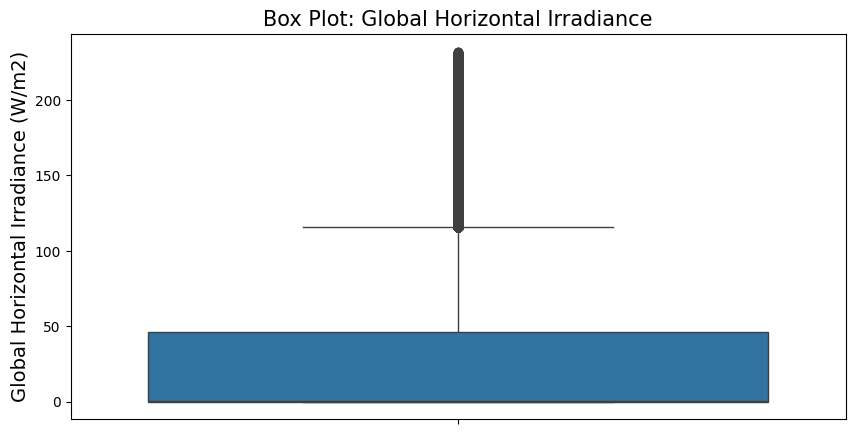

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(clean_Osna_Irrad.GHI)
plt.title('Box Plot: Global Horizontal Irradiance', fontsize=15)
plt.ylabel('Global Horizontal Irradiance (W/m2)', fontsize=14)
plt.show()

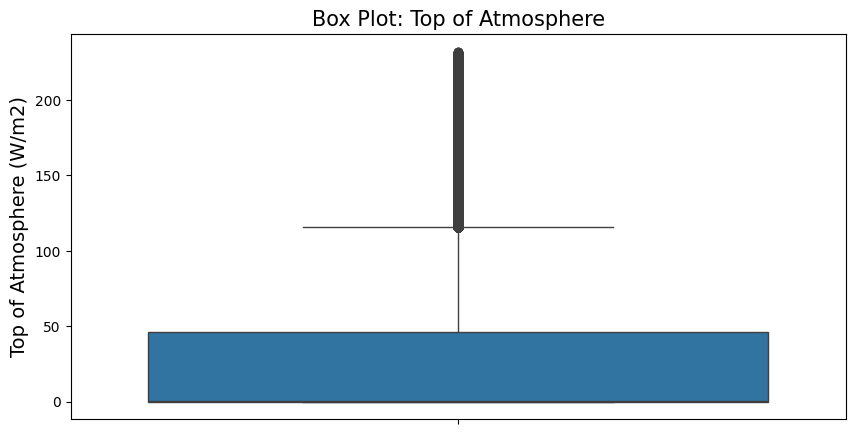

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(clean_Osna_Irrad.GHI)
plt.title('Box Plot: Top of Atmosphere', fontsize=15)
plt.ylabel('Top of Atmosphere (W/m2)', fontsize=14)
plt.show()

In [ ]:
mask_nn = clean_Osna_Irrad['GHI'] == 0.0
clean_Osna_Irrad[mask_nn]

,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI
1546300800000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546301700000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546302600000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546303500000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546304400000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...
1704062700000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704063600000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704064500000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704065400000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000


In [ ]:
mask_n = clean_Osna_Irrad['GHI'] != 0.0
clean_Osna_Irrad[mask_n]

,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI
1546328700000,5.3329,1.4349,0.0718,1.3631,2.0729,1.4349,0.0718,1.3631,2.0729
1546329600000,15.7660,5.3007,0.9644,4.3363,20.2415,5.3007,0.9644,4.3363,20.2415
1546330500000,25.6438,10.3631,3.1630,7.2001,42.7631,10.0959,3.0566,7.0393,41.5029
1546331400000,34.9472,15.9640,6.1786,9.7854,61.8514,6.0256,1.6263,4.3993,17.4100
1546332300000,43.6364,21.7215,9.6655,12.0560,77.7270,2.8030,0.0000,2.8030,0.0000
...,...,...,...,...,...,...,...,...,...
1704032100000,37.2787,18.5582,9.5053,9.0530,89.3682,7.8704,3.2716,4.5988,29.4976
1704033000000,28.1766,12.6443,5.5083,7.1360,68.1383,9.1021,3.6459,5.4562,46.7022
1704033900000,18.4875,7.0706,2.2304,4.8401,41.1014,7.0706,2.2304,4.8401,41.1014
1704034800000,8.2530,2.4725,0.3119,2.1605,9.0982,2.4725,0.3119,2.1605,9.0982


In [ ]:
clean_Osna_Irrad.tail()

,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI
1704062700000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704063600000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704064500000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704065400000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704066300000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000


In [ ]:
float = clean_Osna_Irrad.select_dtypes(include=['object']).columns



In [ ]:
clean_Osna_Irrad.info()

<class 'pandas.core.frame.DataFrame'>
Index: 175296 entries, 1546300800000 to 1704066300000
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TOA            175296 non-null  object 
 1   Clear sky GHI  175296 non-null  object 
 2   Clear sky BHI  175296 non-null  object 
 3   Clear sky DHI  175296 non-null  object 
 4   Clear sky BNI  175296 non-null  object 
 5   GHI            175296 non-null  float64
 6   BHI            175296 non-null  object 
 7   DHI            175296 non-null  object 
 8   BNI            175296 non-null  object 
dtypes: float64(1), object(8)
memory usage: 13.4+ MB


In [ ]:
result = (df_osna['GHI'] == 0.0) & (df_osna['TOA'] == 0.0) & (df_osna['DHI'] == 0.0) & (df_osna['BNI'] == 0.0) & \
         (df_osna['BHI'] == 0.0) & (df_osna['Clear sky GHI'] == 0.0) & (df_osna['Clear sky DHI'] == 0.0) & \
         (df_osna['Clear sky BNI'] == 0.0) & (df_osna['Clear sky BHI'] == 0.0)

df_osna[result]

,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,BHI,DHI,BNI,GHI
1546300800000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1546301700000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1546302600000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1546303500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1546304400000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1704062700000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1704063600000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1704064500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1704065400000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
round((len(df_osna[result])/len(df_osna)) *100, 2)

48.84

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor

# Number of neighbors for LOF
n_neighbors = 20
contamination = 0.10

# Dictionary to store the percentage of outliers for each feature
outlier_percentages = {}

# Apply LOF to each feature
for feature in df_osna.columns:
# Reshape the data for LOF
 X = df_osna[[feature]].values

 # Fit the LOF model
 lof = LocalOutlierFactor(n_neighbors=n_neighbors)
 y_pred = lof.fit_predict(X)

 # Identify the outliers
 outliers = y_pred == -1

 # Calculate the percentage of outliers
 percentage_outliers = np.mean(outliers) * 100
 outlier_percentages[feature] = percentage_outliers

 print(f'Percentage of outliers in osnabrueck irradiation in {feature}: {percentage_outliers:.2f}%')

Percentage of outliers in osnabrueck irradiation in TOA: 0.04%
Percentage of outliers in osnabrueck irradiation in Clear sky GHI: 0.01%
Percentage of outliers in osnabrueck irradiation in Clear sky BHI: 0.07%
Percentage of outliers in osnabrueck irradiation in Clear sky DHI: 0.02%
Percentage of outliers in osnabrueck irradiation in Clear sky BNI: 0.02%
Percentage of outliers in osnabrueck irradiation in BHI: 0.09%
Percentage of outliers in osnabrueck irradiation in DHI: 0.01%
Percentage of outliers in osnabrueck irradiation in BNI: 0.11%
Percentage of outliers in osnabrueck irradiation in GHI: 0.02%


In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm

# Assuming clean_Osna_Irrad is your DataFrame loaded from your dataset
# Example steps to handle data types and missing values

# Step 1: Check and Convert Data Types
# Convert all columns to numeric (float64)
clean_Osna_Irrad = clean_Osna_Irrad.apply(pd.to_numeric, errors='coerce')

# Step 2: Handle Missing Values
clean_Osna_Irrad = clean_Osna_Irrad.dropna()  # Drop rows with NaN values

# Extract features
X = clean_Osna_Irrad.values

# Fit Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable

# Calculate likelihoods for each data point
means = gnb.theta_
variances = np.var(X, axis=0) + 1e-9  # Adding a small value for numerical stability

likelihoods = np.zeros(X.shape[0])

# Ensure means and variances are in correct shape
if means.ndim == 1:
    means = means.reshape(1, -1)
if variances.ndim == 1:
    variances = variances.reshape(1, -1)

# Calculate likelihoods for each data point
for i, x in enumerate(X):
    likelihood = 1
    for j in range(X.shape[1]):
        likelihood *= norm.pdf(x[j], loc=means[0][j], scale=np.sqrt(variances[0][j]))
    likelihoods[i] = likelihood

# Determine anomalies
threshold = np.percentile(likelihoods, 10)  # for example, consider the bottom 10% as anomalies
anomalies = np.where(likelihoods < threshold)[0]

# Calculate percentage of anomalies for each feature
anomalies_clean_Osna_Irrad = clean_Osna_Irrad.iloc[anomalies]
total_anomalies = len(anomalies)
total_data_points = len(clean_Osna_Irrad)

# Calculate anomaly percentage for each feature
feature_anomalies_percentage = {}
for feature in clean_Osna_Irrad.columns:
    feature_anomalies_count = (anomalies_clean_Osna_Irrad[feature] != clean_Osna_Irrad[feature].mode().iloc[0]).sum()
    feature_anomalies_percentage[feature] = (feature_anomalies_count / total_data_points) * 100

print("Number of anomalies detected:", total_anomalies)
print("Percentage of anomalies for each feature:")
for feature, percentage in feature_anomalies_percentage.items():
    print(f"{feature}: {percentage:.2f}%")


Number of anomalies detected: 17530
Percentage of anomalies for each feature:
TOA: 10.00%
Clear sky GHI: 10.00%
Clear sky BHI: 10.00%
Clear sky DHI: 10.00%
Clear sky BNI: 10.00%
GHI: 10.00%
BHI: 9.99%
DHI: 10.00%
BNI: 9.99%


In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm

# Initialize a dictionary to store anomaly information for each feature
anomaly_info = {}

# Loop through each feature
for feature in df_osna.columns:
    # Extract the feature values
    X = df_osna[[feature]].values
    # Fit Gaussian Naive Bayes model
    gnb = GaussianNB()
    gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable
    # Calculate likelihoods for each data point
    means = gnb.theta_
    variances = gnb.var_
    likelihoods = np.zeros(X.shape[0])
    # Ensure means and variances are in correct shape
    if means.ndim == 1:
        means = means.reshape(1, -1)
    if variances.ndim == 1:
        variances = variances.reshape(1, -1)
    # Calculate likelihoods for each data point
    for i, x in enumerate(X):
        likelihood = norm.pdf(x[0], loc=means[0][0], scale=np.sqrt(variances[0][0]))
        likelihoods[i] = likelihood
    # Determine anomalies using mean and standard deviation
    mean_likelihood = np.mean(likelihoods)
    std_likelihood = np.std(likelihoods)
    threshold = mean_likelihood - 2 * std_likelihood  # 2 standard deviations below the mean
    anomalies = np.where(likelihoods < threshold)[0]
    # Calculate percentage of anomalies for this feature
    total_anomalies = len(anomalies)
    total_data_points = len(df_osna)
    anomaly_percentage = (total_anomalies / total_data_points) * 100

    # Store the anomaly information
    anomaly_info[feature] = {
        'total_anomalies': total_anomalies,
        'anomaly_percentage': anomaly_percentage,
        'anomalies': anomalies
    }

# Print results
for feature, info in anomaly_info.items():
    print(f"Feature: {feature}")
    print(f"  Number of anomalies detected: {info['total_anomalies']}")
    print(f"  Percentage of anomalies: {info['anomaly_percentage']:.2f}%")



Feature: TOA
  Number of anomalies detected: 16339
  Percentage of anomalies: 9.32%
Feature: Clear sky GHI
  Number of anomalies detected: 17189
  Percentage of anomalies: 9.81%
Feature: Clear sky BHI
  Number of anomalies detected: 17402
  Percentage of anomalies: 9.93%
Feature: Clear sky DHI
  Number of anomalies detected: 13364
  Percentage of anomalies: 7.62%
Feature: Clear sky BNI
  Number of anomalies detected: 9889
  Percentage of anomalies: 5.64%
Feature: BHI
  Number of anomalies detected: 15564
  Percentage of anomalies: 8.88%
Feature: DHI
  Number of anomalies detected: 15833
  Percentage of anomalies: 9.03%
Feature: BNI
  Number of anomalies detected: 18794
  Percentage of anomalies: 10.72%
Feature: GHI
  Number of anomalies detected: 16997
  Percentage of anomalies: 9.70%


AUTOENCODER ON IRRADIATION DATA

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential



#to save all features
features_auto_i = clean_Osna_Irrad.columns.tolist()


# DataFrame to store anomaly scores for each feature
anomaly_scores_auto_i = pd.DataFrame(index=clean_Osna_Irrad.index)

# Loop through each feature
for feature in features_auto_i :
    # Scale the feature data
    scaler = MinMaxScaler()
    scaled_feature_auto_i  = scaler.fit_transform(clean_Osna_Irrad[[feature]])

    # Define the autoencoder model
    model_auto_i  = Sequential([
        Dense(32, activation='relu', input_shape=(1,)),
        Dense(16, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model_auto_i .compile(optimizer='adam', loss='mean_squared_error')

     #Train the autoencoder
    model_auto_i.fit(scaled_feature_auto_i , scaled_feature_auto_i , epochs=50, batch_size=32, validation_split=0.1, verbose=0)

    # Get reconstruction loss
    reconstructed_feature_auto_i  = model_auto_i.predict(scaled_feature_auto_i)
    reconstruction_loss_auto_i  = np.mean(np.square(scaled_feature_auto_i  - reconstructed_feature_auto_i), axis=1)

    # Store the reconstruction loss (anomaly score) in the DataFrame
    anomaly_scores_auto_i [feature] = reconstruction_loss_auto_i



5478/5478 [==============================] - 10s 2ms/step


In [ ]:

print(reconstruction_loss_auto_i)
# Calculate the threshold as the 90th percentile of the reconstruction loss
threshold_auto_i = np.percentile(reconstruction_loss_auto_i, 90)

    # Identify anomalies
anomalies_auto_i = reconstruction_loss_auto_i > threshold_auto_i

for feature in features_auto_i:
    anomalies_auto_i = anomaly_scores_auto_i[feature] > threshold_auto_i
    anomaly_percentage_auto_i = np.mean(anomalies_auto_i) * 100
    print(f'Feature: {feature}, Anomaly Percentage: {anomaly_percentage_auto_i:.2f}%')


    # Store the reconstruction loss (anomaly score) in the DataFrame
anomaly_scores_auto_i[feature] = reconstruction_loss_auto_i


# Combine anomaly scores with original data for easier analysis
combined_data_auto_i = pd.concat([clean_Osna_Irrad, anomaly_scores_auto_i.add_suffix('_anomaly_score')], axis=1)

# Save the combined data with anomaly scores
combined_data_auto_i.to_csv('clean_Osna_Irrad_with_anomaly_scores_auto_i.csv', index=False)

# Display the first few rows of the combined data
combined_data_auto_i.head()






[2.02027478e-08 2.02027478e-08 2.02027478e-08 ... 2.02027478e-08
 2.02028636e-08 2.02028636e-08]
Feature: TOA, Anomaly Percentage: 15.75%
Feature: Clear sky GHI, Anomaly Percentage: 5.83%
Feature: Clear sky BHI, Anomaly Percentage: 25.76%
Feature: Clear sky DHI, Anomaly Percentage: 1.64%
Feature: Clear sky BNI, Anomaly Percentage: 20.76%
Feature: GHI, Anomaly Percentage: 10.03%
Feature: BHI, Anomaly Percentage: 3.76%
Feature: DHI, Anomaly Percentage: 0.52%
Feature: BNI, Anomaly Percentage: 10.00%


,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI,TOA_anomaly_score,Clear sky GHI_anomaly_score,Clear sky BHI_anomaly_score,Clear sky DHI_anomaly_score,Clear sky BNI_anomaly_score,GHI_anomaly_score,BHI_anomaly_score,DHI_anomaly_score,BNI_anomaly_score
1546300800000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,1.061122e-07,1.647116e-08,1.366798e-07,2.937836e-08,4.509981e-09,4.721128e-08,9.599645e-09,1.168177e-08,2.020275e-08
1546301700000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,1.061122e-07,1.647116e-08,1.366798e-07,2.937836e-08,4.509981e-09,4.721128e-08,9.599645e-09,1.168177e-08,2.020275e-08
1546302600000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,1.061122e-07,1.647116e-08,1.366798e-07,2.937836e-08,4.509981e-09,4.721128e-08,9.599645e-09,1.168177e-08,2.020275e-08
1546303500000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,1.061122e-07,1.647116e-08,1.366798e-07,2.937836e-08,4.509981e-09,4.721128e-08,9.599645e-09,1.168177e-08,2.020275e-08
1546304400000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,1.061122e-07,1.647116e-08,1.366798e-07,2.937836e-08,4.509981e-09,4.721128e-08,9.599645e-09,1.168177e-08,2.020275e-08


APPLYING XGBOOST ON IRRRADIATION DATASET

In [ ]:

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Sample Data (Replace with your dataset)
# Assuming a dataframe with 100 rows and 10 features


# Define anomaly detection function
def detect_anomalies(Mun_df):
    anomalies = pd.DataFrame(index=Mun_df.index)
    anomaly_percentages = {}

    for feature in Mun_df.columns:
        X = Mun_df.drop(columns=[feature])
        y = Mun_df[feature]

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Train XGBoost model
        model = XGBRegressor()
        model.fit(X_train, y_train)

        # Predict on the whole dataset
        y_pred = model.predict(X)

        # Calculate prediction errors
        errors = np.abs(y - y_pred)

        # Determine dynamic threshold using standard deviation
        mean_error = np.mean(errors)
        std_error = np.std(errors)
        threshold = mean_error + 2 * std_error  # Consider 2 standard deviations from the mean

        # Flag anomalies
        anomaly_flags = errors > threshold
        anomalies[feature] = anomaly_flags

        # Calculate anomaly percentage
        anomaly_percentages[feature] = (anomaly_flags.sum() / len(Mun_df)) * 100

        # Print summary
        print(f"Feature: {feature}")
        print(f"Threshold: {threshold:.4f}")
        print(f"Anomalies detected: {anomaly_flags.sum()}/{len(Mun_df)} ({anomaly_percentages[feature]:.2f}%)")
        print("-" * 40)

    return anomalies, anomaly_percentages

# Detect anomalies
anomalies_df, anomaly_percentages = detect_anomalies(df_osna)


# Print anomaly percentages
print("\nAnomaly Percentages per Feature:")
for feature, percentage in anomaly_percentages.items():
    print(f"{feature}: {percentage:.2f}%")


Feature: TOA
Threshold: 2.0840
Anomalies detected: 9827/175296 (5.61%)
----------------------------------------
Feature: Clear sky GHI
Threshold: 1.0121
Anomalies detected: 9742/175296 (5.56%)
----------------------------------------
Feature: Clear sky BHI
Threshold: 0.9124
Anomalies detected: 10046/175296 (5.73%)
----------------------------------------
Feature: Clear sky DHI
Threshold: 1.2775
Anomalies detected: 9688/175296 (5.53%)
----------------------------------------
Feature: Clear sky BNI
Threshold: 4.0490
Anomalies detected: 10225/175296 (5.83%)
----------------------------------------
Feature: BHI
Threshold: 0.8905
Anomalies detected: 9260/175296 (5.28%)
----------------------------------------
Feature: DHI
Threshold: 1.1823
Anomalies detected: 8839/175296 (5.04%)
----------------------------------------
Feature: BNI
Threshold: 2.5553
Anomalies detected: 8917/175296 (5.09%)
----------------------------------------
Feature: GHI
Threshold: 1.1649
Anomalies detected: 8140/175296